In [4]:
import numpy as np
from matplotlib import pyplot as plt
import pickle as pkl
import seaborn as sns
import pandas as pd
from glob import glob
from tqdm import tqdm
from pathlib import Path


### Regional Hierarchy


#### Plots for cortical hierarchy from Harris et.al (2019)

- **For Target = Variable, sources = neurons**
  -   Syn/Redundancy ratio in different intervals
  -   MI coded for in different intervals
  -   Correlation with hierarchical score <br>
- **For Target = Neurons, sources = neurons**
  - Shared information / how much one neuron determines another


In [2]:
# load files
def return_data_files(key='stim',norm='neuron'):
    """
    Args:
        key (str, optional): Which kind of files to return. Defaults to 'stim', can be 'feedback' or 'choice'.
    """
    if norm=='neuron' or norm=='all' or norm=='none':
        data_files = glob(f'../data/interim/hieararchy insertions/{norm}_normalization/*_{key}_*.pkl')
    elif norm=='regional':
        data_files = glob(f'../data/interim/hieararchy insertions/regional_information/*_{key}_*.pkl')
    return data_files

In [3]:
def gather_data(key, norm):
    """
    Returns the data for each region depending on the key and the normalization

    Args:
        key (string): Epoch to consider
        norm (string): Normalization to load

    Returns:
        region (dict): All regions for a particular epoch
    """
    files = return_data_files(key, norm)
    regions = {}
    # labels = ['u1','u2','red','syn','mi_yx1','mi_yx2','coinfo','mi_yx1x2']
    hits_per_region = {}

    for each_file in tqdm(files):
        with open(each_file,'rb') as f:
            data = pkl.load(f)  
        
        for k in data.keys():
            pid_region = data[k]
            # now for each region, we compute the mean syn and red
            mean_synergy = np.mean(pid_region,axis=0)[3]
            mean_redundancy = np.mean(pid_region,axis=0)[2]
            mean_mutual_information = np.mean(pid_region,axis=0)[7]
            mean_unique = (np.mean(pid_region,axis=0)[0] + np.mean(pid_region,axis=0)[1])/2

            if k in regions.keys():
                regions[k].append([mean_synergy, mean_redundancy, mean_mutual_information, mean_unique])
                hits_per_region[k] = hits_per_region[k]+1
            else:
                regions[k] = [[mean_synergy, mean_redundancy, mean_mutual_information, mean_unique]]
                hits_per_region[k] = 1
    return regions, hits_per_region

def get_mapping_to(df, areas):
    """
    region to area mapping from Harris et.al

    Args:
        df (pandas dataframe): data from harris et. al
        areas (np.array): regions we have in our data

    Returns:
        regionwide, sort_idx: valid regions, indices to order region
    """
    
    # get areas that have been made into ROIs
    regionwide = np.isin(areas, df['areas'])
    regionwide_areas = areas[regionwide]

    area_to_region = dict(zip(df['areas'], df['Region']))
    regions_array = np.array([area_to_region[area] for area in regionwide_areas])
    sort_idx = np.argsort(regions_array)

    return regionwide, sort_idx

In [4]:
def plot_epochs(data_a, data_b, data_c, df, compute_mean_across_regions=False, scatter=False, ratio = False):

    
    total_regions = len(data_a.keys())


    pid_data_a_mean = np.zeros((total_regions, 4))
    pid_data_a_std = np.zeros((total_regions, 4))
    pid_data_b_mean = np.zeros((total_regions, 4))
    pid_data_b_std = np.zeros((total_regions, 4))
    pid_data_c_mean = np.zeros((total_regions, 4))
    pid_data_c_std = np.zeros((total_regions, 4))

    for idx, k in enumerate(data_a.keys()):
        temp = np.asarray(data_a[k])
        pid_data_a_mean[idx, :] = np.mean(temp, axis=0)
        pid_data_a_std[idx, :] = np.mean(temp, axis=0)

        temp = np.asarray(data_b[k])
        pid_data_b_mean[idx, :] = np.mean(temp, axis=0)
        pid_data_b_std[idx, :] = np.mean(temp, axis=0)

        temp = np.asarray(data_c[k])
        pid_data_c_mean[idx, :] = np.mean(temp, axis=0)
        pid_data_c_std[idx, :] = np.mean(temp, axis=0)
    

    # sort by region
    areas = np.asarray(list(data_a.keys()))
    regionwide, sort_idx = get_mapping_to(df, areas)
    total_regions = np.sum(regionwide)
    areas = areas[regionwide][sort_idx]

    #filter all data and sort
    pid_data_a_mean = np.round(pid_data_a_mean[regionwide, :][sort_idx], 6)
    pid_data_a_std = np.round(pid_data_a_std[regionwide, :][sort_idx], 6)
    pid_data_b_mean = np.round(pid_data_b_mean[regionwide, :][sort_idx], 6)
    pid_data_b_std = np.round(pid_data_b_std[regionwide, :][sort_idx], 6)
    pid_data_c_mean = np.round(pid_data_c_mean[regionwide, :][sort_idx], 6)
    pid_data_c_std = np.round(pid_data_c_std[regionwide, :][sort_idx], 6)
    

    if compute_mean_across_regions==False:

        fig, ax = plt.subplots(figsize=(16,6), nrows=2, sharex=True,layout='constrained', sharey=True)
        
        ax[0].bar(np.arange(total_regions)-0.3, pid_data_a_mean[:, 0],label='Stim', width=0.3,color='blue', alpha=0.75, edgecolor='k', yerr=pid_data_a_std[:,0]/2)
        ax[0].bar(np.arange(total_regions), pid_data_b_mean[:, 0],label='Choice', width=0.3,color='orange', alpha=0.75, edgecolor='k', yerr=pid_data_b_std[:,0]/2)
        ax[0].bar(np.arange(total_regions)+0.3, pid_data_c_mean[:, 0],label='Feedback', width=0.3,color='red', alpha=0.75, edgecolor='k', yerr=pid_data_c_std[:,0]/2)

        if scatter==True:
            ax[1].errorbar(np.arange(total_regions)-0.3, pid_data_a_mean[:, 3],label='Stim',color='blue', alpha=0.75, yerr=pid_data_a_std[:,3]/2, fmt='o', markeredgecolor ='k')
            ax[1].errorbar(np.arange(total_regions), pid_data_b_mean[:, 3],label='Choice',color='orange', alpha=0.75, yerr=pid_data_b_std[:,3]/2, fmt='o', markeredgecolor ='k')
            ax[1].errorbar(np.arange(total_regions)+0.3, pid_data_c_mean[:, 3],label='Feedback',color='red', alpha=0.75, yerr=pid_data_c_std[:,3]/2, fmt='o', markeredgecolor ='k')

            ax[0].errorbar(np.arange(total_regions)-0.3, pid_data_a_mean[:, 3],label='Stim',color='blue', alpha=0.75, yerr=pid_data_a_std[:,3]/2, fmt='o', markeredgecolor ='k')
            ax[0].errorbar(np.arange(total_regions), pid_data_b_mean[:, 3],label='Choice',color='orange', alpha=0.75, yerr=pid_data_b_std[:,3]/2, fmt='o', markeredgecolor ='k')
            ax[0].errorbar(np.arange(total_regions)+0.3, pid_data_c_mean[:, 3],label='Feedback',color='red', alpha=0.75, yerr=pid_data_c_std[:,3]/2, fmt='o', markeredgecolor ='k')


            ax[1].errorbar(np.arange(total_regions)-0.3, pid_data_a_mean[:, 2],label='Stim',color='blue', alpha=0.75, yerr=pid_data_a_std[:,2]/2, fmt='*', markeredgecolor ='k')
            ax[1].errorbar(np.arange(total_regions), pid_data_b_mean[:, 2],label='Choice',color='orange', alpha=0.75, yerr=pid_data_b_std[:,2]/2, fmt='*', markeredgecolor ='k')
            ax[1].errorbar(np.arange(total_regions)+0.3, pid_data_c_mean[:, 2],label='Feedback',color='red', alpha=0.75, yerr=pid_data_c_std[:,2]/2, fmt='*', markeredgecolor ='k')

            ax[0].errorbar(np.arange(total_regions)-0.3, pid_data_a_mean[:, 2],label='Stim',color='blue', alpha=0.75, yerr=pid_data_a_std[:,2]/2, fmt='*', markeredgecolor ='k')
            ax[0].errorbar(np.arange(total_regions), pid_data_b_mean[:, 2],label='Choice',color='orange', alpha=0.75, yerr=pid_data_b_std[:,2]/2, fmt='*', markeredgecolor ='k')
            ax[0].errorbar(np.arange(total_regions)+0.3, pid_data_c_mean[:, 2],label='Feedback',color='red', alpha=0.75, yerr=pid_data_c_std[:,2]/2, fmt='*', markeredgecolor ='k')
        
        if ratio == True:
            ax[0].scatter(np.arange(total_regions)-0.3, pid_data_a_mean[:, 0]/pid_data_a_mean[:, 1],label='Stim',color='blue', alpha=0.75)
            ax[0].scatter(np.arange(total_regions), pid_data_b_mean[:, 0]/pid_data_b_mean[:, 1],label='Choice',color='orange', alpha=0.75)
            ax[0].scatter(np.arange(total_regions)+0.3, pid_data_c_mean[:, 0]/pid_data_c_mean[:, 1],label='Feedback',color='red', alpha=0.75)

        # ax.bar(np.arange(total_regions)+0.25, pid_data_mean[:, 1], width=0.25, label='Redundancy')
        labels = list(data_a.keys())
        ax[0].set_xticks(np.arange(total_regions), areas, rotation=90)
        ax[0].set_title(f'Synergy for all epochs')


        ax[1].bar(np.arange(total_regions)-0.3, pid_data_a_mean[:, 1],label='Stim', width=0.3,color='blue', alpha=0.75, edgecolor='k', yerr=pid_data_a_std[:,1]/2)
        ax[1].bar(np.arange(total_regions), pid_data_b_mean[:, 1],label='Choice', width=0.3,color='orange', alpha=0.75, edgecolor='k', yerr=pid_data_b_std[:,1]/2)
        ax[1].bar(np.arange(total_regions)+0.3, pid_data_c_mean[:, 1],label='Feedback', width=0.3,color='red', alpha=0.75, edgecolor='k', yerr=pid_data_c_std[:,1]/2)
        # ax.bar(np.arange(total_regions)+0.25, pid_data_mean[:, 1], width=0.25, label='Redundancy')
        ax[1].set_xticks(np.arange(total_regions), areas, rotation=90)
        ax[1].set_title(f'Redundancy for all epochs')
        plt.legend()
        # needed for second axis
        area_to_region = dict(zip(df['areas'], df['Region']))

        
        regions = np.array([area_to_region[a] for a in areas])

        values = ['\n\n\n\n'+v for v in regions]
        sec = ax[1].secondary_xaxis(location='top')
        
        sec.set_xticks(np.arange(len(regions))-0.5, labels=values,rotation=90)
        sec.tick_params('x', length=0)
        # ax[1].xaxis.set_xticks(np.arange(len(regions)))
        # ax[1].xaxis.set_xticklabels(regions, rotation=0)
        # ax[1].xaxis.set_xlim(ax[1].get_xlim())

    elif compute_mean_across_regions==True:
        area_to_region = dict(zip(df['areas'], df['Region']))
        regions = np.array([area_to_region[a] for a in areas])

        unique_regions = np.unique(regions)
        averages_data_a = np.zeros((len(unique_regions), 4))
        averages_data_b = np.zeros((len(unique_regions), 4))
        averages_data_c = np.zeros((len(unique_regions), 4))

        deviations_data_a = np.zeros((len(unique_regions), 4))
        deviations_data_b = np.zeros((len(unique_regions), 4))
        deviations_data_c = np.zeros((len(unique_regions), 4))

        for i, region in enumerate(unique_regions):
            region_indices = np.where(regions == region)
            averages_data_a[i,:] = np.mean(pid_data_a_mean[region_indices,:], axis=1)
            averages_data_b[i,:] = np.mean(pid_data_b_mean[region_indices,:], axis=1)
            averages_data_c[i,:] = np.mean(pid_data_c_mean[region_indices,:], axis=1)

            deviations_data_a[i,:] = np.std(pid_data_a_mean[region_indices,:], axis=1)/2
            deviations_data_b[i,:] = np.std(pid_data_b_mean[region_indices,:], axis=1)/2
            deviations_data_c[i,:] = np.std(pid_data_c_mean[region_indices,:], axis=1)/2


        # now we plot

        fig, ax = plt.subplots(figsize=(16,6), nrows=2, sharex=True,layout='constrained', sharey=True)
        print('here i am')
        ax[0].bar(np.arange(len(unique_regions))-0.3, averages_data_a[:, 0],label='Stim', width=0.3,color='blue', alpha=0.75, edgecolor='k', yerr=deviations_data_a[:,0]/2)
        ax[0].bar(np.arange(len(unique_regions)), averages_data_b[:, 0],label='Choice', width=0.3,color='orange', alpha=0.75, edgecolor='k', yerr=deviations_data_b[:,0]/2)
        ax[0].bar(np.arange(len(unique_regions))+0.3, averages_data_c[:, 0],label='Feedback', width=0.3,color='red', alpha=0.75, edgecolor='k', yerr=deviations_data_c[:,0]/2)

        if scatter==True:

            ax[1].errorbar(np.arange(len(unique_regions))-0.3, averages_data_a[:, 3],label='Stim',color='blue', alpha=0.75, yerr=deviations_data_a[:,3]/2, fmt='o', markeredgecolor ='k')
            ax[1].errorbar(np.arange(len(unique_regions)), averages_data_b[:, 3],label='Choice',color='orange', alpha=0.75, yerr=deviations_data_b[:,3]/2, fmt='o', markeredgecolor ='k')
            ax[1].errorbar(np.arange(len(unique_regions))+0.3, averages_data_c[:, 3],label='Feedback',color='red', alpha=0.75, yerr=deviations_data_c[:,3]/2, fmt='o', markeredgecolor ='k')

            ax[0].errorbar(np.arange(len(unique_regions))-0.3, averages_data_a[:, 3],label='Stim',color='blue', alpha=0.75, yerr=deviations_data_a[:,3]/2, fmt='o', markeredgecolor ='k')
            ax[0].errorbar(np.arange(len(unique_regions)), averages_data_b[:, 3],label='Choice',color='orange', alpha=0.75, yerr=deviations_data_b[:,3]/2, fmt='o', markeredgecolor ='k')
            ax[0].errorbar(np.arange(len(unique_regions))+0.3, averages_data_c[:, 3],label='Feedback',color='red', alpha=0.75, yerr=deviations_data_c[:,3]/2, fmt='o', markeredgecolor ='k')


        # ax.bar(np.arange(len(unique_regions))+0.25averagesid_data[:, 1], width=0.25, label='Redundancy')
        ax[0].set_xticks(np.arange(len(unique_regions)), unique_regions, rotation=90)
        ax[0].set_title(f'Synergy for all epochs')


        ax[1].bar(np.arange(len(unique_regions))-0.3, averages_data_a[:, 1],label='Stim', width=0.3,color='blue', alpha=0.75, edgecolor='k', yerr=deviations_data_a[:,1]/2)
        ax[1].bar(np.arange(len(unique_regions)), averages_data_b[:, 1],label='Choice', width=0.3,color='orange', alpha=0.75, edgecolor='k', yerr=deviations_data_b[:,1]/2)
        ax[1].bar(np.arange(len(unique_regions))+0.3, averages_data_c[:, 1],label='Feedback', width=0.3,color='red', alpha=0.75, edgecolor='k', yerr=deviations_data_c[:,1]/2)
        # ax.bar(np.arange(len(unique_regions))+0.25averagesid_data[:, 1], width=0.25, label='Redundancy')
        ax[1].set_xticks(np.arange(len(unique_regions)), unique_regions, rotation=90)
        ax[1].set_title(f'Redundancy for all epochs')
        plt.legend()

In [5]:
df_region_mapping = pd.read_csv('../data/processed/region_mapping.csv')
df_global_score = pd.read_csv('../data/processed/global_hierarchy.csv')

In [6]:
stim_data, hits_per_stim = gather_data('stim','neuron')
feedback_data, hits_per_feedback = gather_data('feedback','neuron')
choice_data, hits_per_choice = gather_data('choice','neuron')

  0%|          | 0/22 [00:00<?, ?it/s]

100%|██████████| 22/22 [00:00<00:00, 204.28it/s]


In [7]:
def organize_areas(data, df=None):
    if df==None:
        df = pd.read_csv('../data/processed/global_hierarchy.csv')
    areas = np.asarray(list(data.keys()))
    area_to_rank = dict(zip(df['areas'], df['ordinal_rank']))
    area_ranking = np.asarray([area_to_rank[a] for a in areas])
    sort_idx = np.argsort(area_ranking)
    return sort_idx

In [19]:
def plot_syn_red(data, epoch, sort_by_h = False):
    total_regions = len(data.keys())

    pid_data_mean = np.zeros((total_regions, 4))
    pid_data_std = np.zeros((total_regions, 4))

    for idx, k in enumerate(data.keys()):
        temp = np.asarray(data[k])
        pid_data_mean[idx, :] = np.mean(temp, axis=0)
        pid_data_std[idx, :] = np.std(temp, axis=0)
    
    if sort_by_h==True:
        sort_idx = organize_areas(data)
        pid_data_mean = pid_data_mean[sort_idx, :]
        pid_data_std = pid_data_std[sort_idx, :]

    fig, ax = plt.subplots(figsize=(16,6), nrows=2)
    ax[0].bar(np.arange(total_regions)-0.25, pid_data_mean[:, 0], width=0.25,label='Synergy',yerr=pid_data_std[:,0]/2,color='green')
    ax[0].bar(np.arange(total_regions), pid_data_mean[:, 1], width=0.25, label='Redundancy',yerr=pid_data_std[:,1]/2,color='blue')
    ax[0].bar(np.arange(total_regions)+0.25, pid_data_mean[:, 3],label='Average Unique',yerr=pid_data_std[:,3]/2, width=0.25,alpha=0.75,color='red')
    
    # total_mi = pid_data_mean[:, 0]+pid_data_mean[:, 1]+pid_data_mean[:, 3]*2)/pid_data_mean[:,2]
    # ax[1].bar(np.arange(total_regions)-0.25, total, width=0.25,label='Proportion Sum',yerr=pid_data_std[:,0]/2,color='green')
    ax[1].bar(np.arange(total_regions)-0.25, pid_data_mean[:, 0]/pid_data_mean[:,2], width=0.25,label='Proportion of Synergy',yerr=pid_data_std[:,0]/2,color='green')
    ax[1].bar(np.arange(total_regions), pid_data_mean[:, 1]/pid_data_mean[:,2], width=0.25, label='Proportion of Redundancy',yerr=pid_data_std[:,1]/2,color='blue')
    ax[1].bar(np.arange(total_regions)+0.25, pid_data_mean[:, 3]*2/pid_data_mean[:,2],label='Proportion of Unique',yerr=pid_data_std[:,3]/2, width=0.25,alpha=0.75,color='red')
    
    labels = np.asarray(list(data.keys()))
    if sort_by_h:
        labels = labels[sort_idx]

    ax[1].set_xticks(np.arange(total_regions), labels, rotation=90)
    ax[0].set_title(f'Synergy-Redundancy for {epoch}')
    ax[1].set_title(f'Proportions for {epoch}')
    ax[0].legend()
    ax[1].legend()

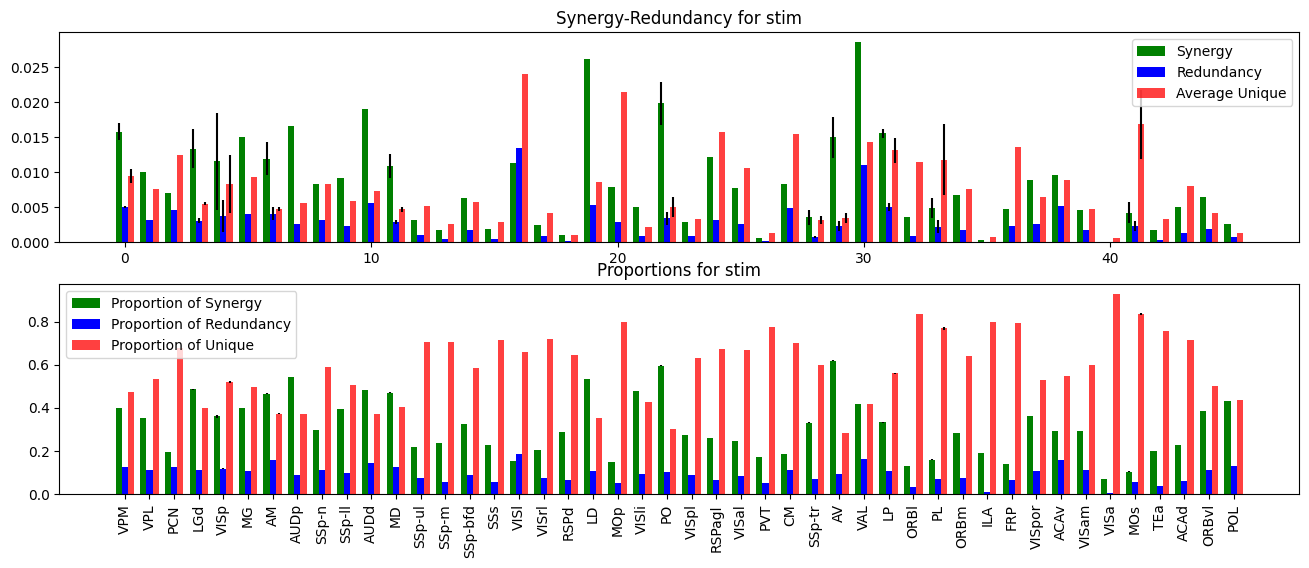

In [20]:
plot_syn_red(stim_data, 'stim', True)

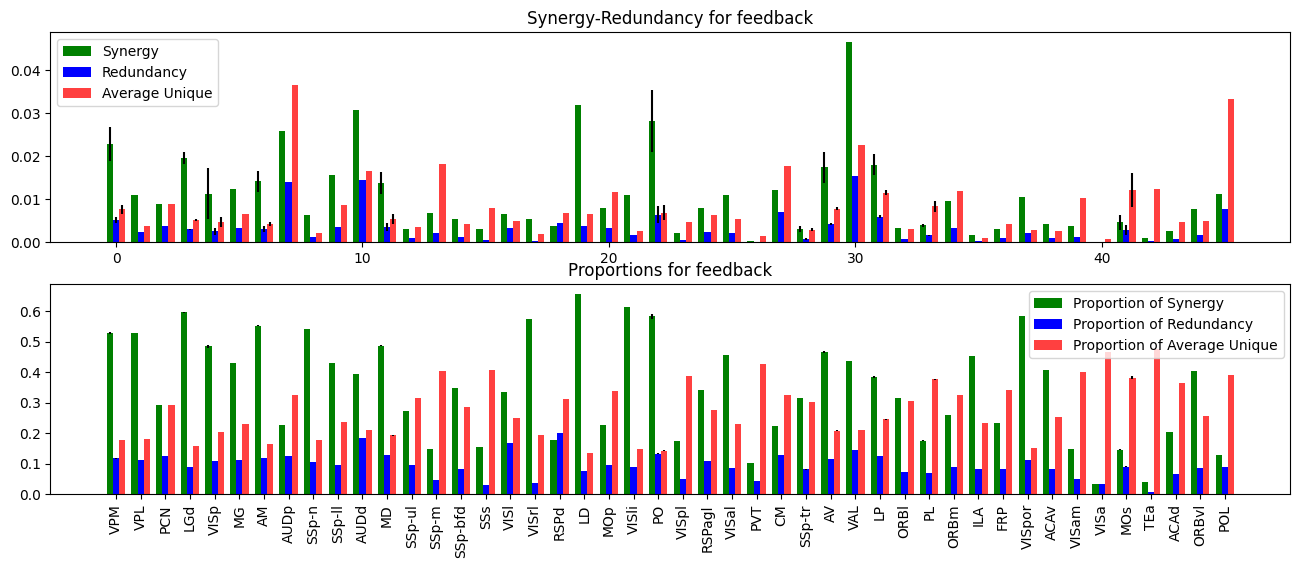

In [646]:
plot_syn_red(feedback_data, 'feedback', True)

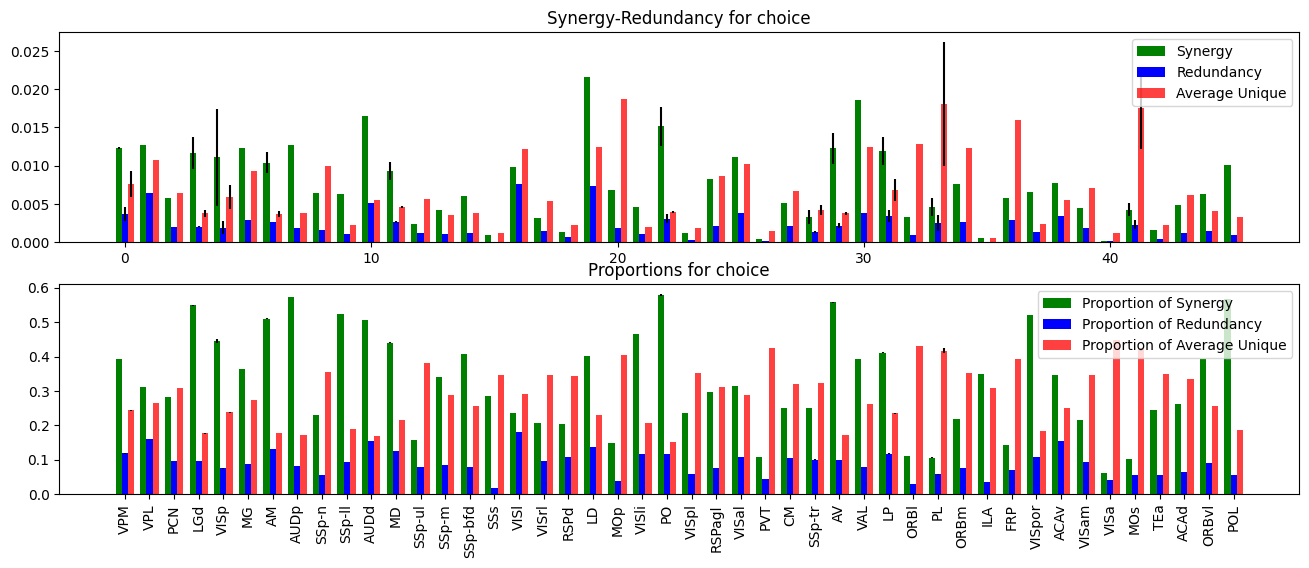

In [647]:
plot_syn_red(choice_data, 'choice', True)

In [21]:
# look at at the trivariate mutual information for feedback

In [28]:
def plot_trivariate(data_stim, data_choice, data_feedback):

    total_regions = len(data_stim.keys())

    pid_data_stim_mean = np.zeros((total_regions, 4))
    pid_data_stim_std = np.zeros((total_regions, 4))

    pid_data_choice_mean = np.zeros((total_regions, 4))
    pid_data_choice_std = np.zeros((total_regions, 4))

    pid_data_feedback_mean = np.zeros((total_regions, 4))
    pid_data_feedback_std = np.zeros((total_regions, 4))


    for idx, k in enumerate(data_choice.keys()):
        
        temp = np.asarray(data_stim[k])
        pid_data_stim_mean[idx, :] = np.mean(temp, axis=0)
        pid_data_stim_std[idx, :] = np.std(temp, axis=0)

        temp = np.asarray(data_choice[k])
        pid_data_choice_mean[idx, :] = np.mean(temp, axis=0)
        pid_data_choice_std[idx, :] = np.std(temp, axis=0)

        temp = np.asarray(data_feedback[k])
        pid_data_feedback_mean[idx, :] = np.mean(temp, axis=0)
        pid_data_feedback_std[idx, :] = np.std(temp, axis=0)
    
    
    sort_idx = organize_areas(data_stim)
    pid_data_stim_mean = pid_data_stim_mean[sort_idx, :]
    pid_data_stim_std = pid_data_stim_std[sort_idx, :]

    pid_data_choice_mean = pid_data_choice_mean[sort_idx, :]
    pid_data_choice_std = pid_data_choice_std[sort_idx, :]

    pid_data_feedback_mean = pid_data_feedback_mean[sort_idx, :]
    pid_data_feedback_std = pid_data_feedback_std[sort_idx, :]

    fig, ax = plt.subplots(figsize=(16,6), nrows=1)

    A1 = pid_data_stim_mean[:,2]
    A2 = pid_data_choice_mean[:,2]
    A3  = pid_data_feedback_mean[:,2]
    ax.bar(np.arange(total_regions)-0.25, pid_data_stim_mean[:,2], width=0.25,label='Stim',yerr=pid_data_stim_std[:,2]/2,color='green')
    ax.bar(np.arange(total_regions), pid_data_choice_mean[:,2], width=0.25, label='Choice',yerr=pid_data_choice_std[:,2]/2,color='blue')
    ax.bar(np.arange(total_regions)+0.25, pid_data_feedback_mean[:,2],label='Feedback',yerr=pid_data_feedback_std[:,2]/2, width=0.25,alpha=0.75,color='red')
    
    # total_mi = pid_data_mean[:, 0]+pid_data_mean[:, 1]+pid_data_mean[:, 3]*2)/pid_data_mean[:,2]
    # ax[1].bar(np.arange(total_regions)-0.25, total, width=0.25,label='Proportion Sum',yerr=pid_data_std[:,0]/2,color='green')
    # ax[1].bar(np.arange(total_regions)-0.25, pid_data_mean[:, 0]/pid_data_mean[:,2], width=0.25,label='Proportion of Synergy',yerr=pid_data_std[:,0]/2,color='green')
    # ax[1].bar(np.arange(total_regions), pid_data_mean[:, 1]/pid_data_mean[:,2], width=0.25, label='Proportion of Redundancy',yerr=pid_data_std[:,1]/2,color='blue')
    # ax[1].bar(np.arange(total_regions)+0.25, pid_data_mean[:, 3]*2/pid_data_mean[:,2],label='Proportion of Unique',yerr=pid_data_std[:,3]/2, width=0.25,alpha=0.75,color='red')
    
    labels = np.asarray(list(data_stim.keys()))
    labels = labels[sort_idx]

    ax.set_xticks(np.arange(total_regions), labels, rotation=90)
    
    ax.legend()

    return np.stack([A1, A2, A3])
    

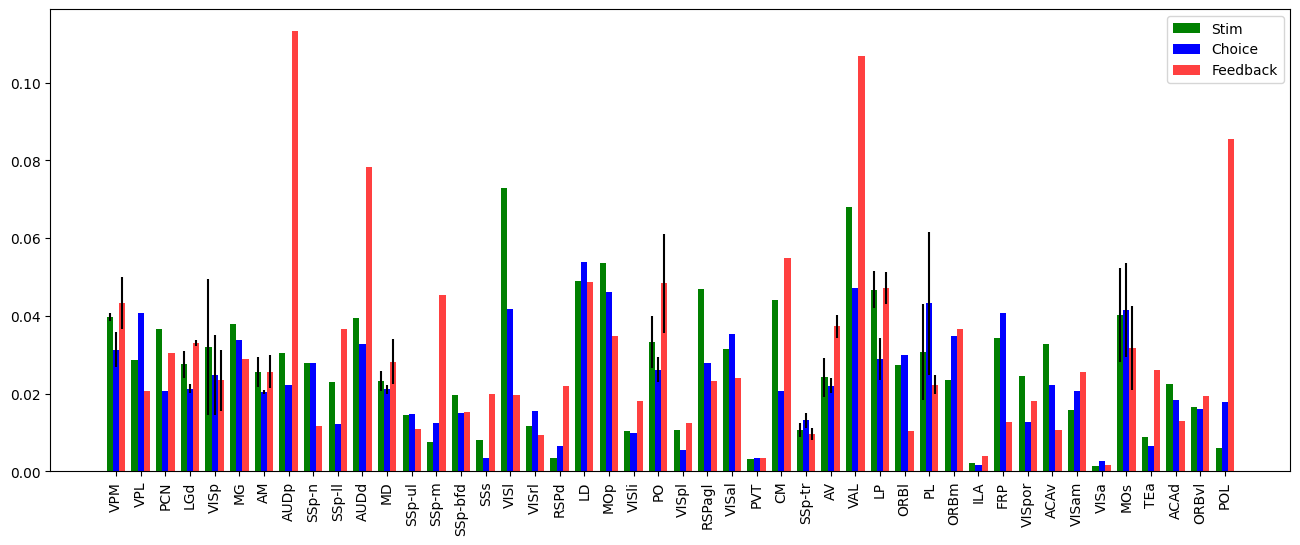

In [29]:
X = plot_trivariate(stim_data, choice_data, feedback_data)

In [33]:
values = np.argmax(X, axis=0)

In [35]:
unique, count  = np.unique(values, return_counts=True)

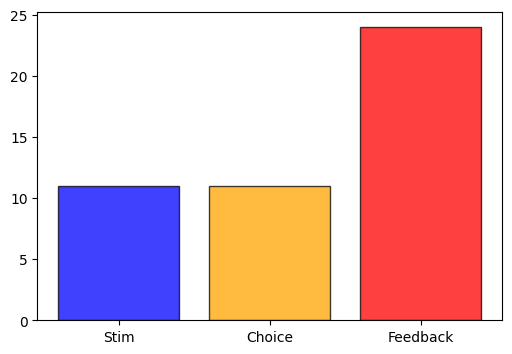

In [40]:
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(np.arange(len(unique)), count, color=['blue','orange','red'], edgecolor='k', alpha=0.75)
ax.set_xticks(np.arange(3), labels=['Stim','Choice','Feedback'])

In [42]:
eids = np.load('../data/processed/eids_with_detailed_insertions.npy', allow_pickle=True)

In [43]:
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.behavior.wheel import velocity
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path

from ibl_info.broja_pid import compute_pid, coinformation
from ibl_info.utility import discretize_neural_data
from ibl_info.prepare_data_pid import prepare_ephys_data, compute_intervals
from brainwidemap.bwm_loading import merge_probes
from ibl_info.load_glm_hmm import load_state_dataframe


c:\Users\debot\miniconda3\envs\info-decom\lib\site-packages\ibllib\atlas\__init__.py:205: DeprecationWarning: ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use this module instead
  warnings.warn('ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use '


In [78]:
def return_distribution(epoch, one):

    d = []
    for session_id in eids:
        if epoch=='stim':
            trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=False)
        else:
            trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)
        intervals, decoding_variable = compute_intervals(trials[mask], epoch)
        d.append(decoding_variable)
    return d


In [45]:
one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")

In [89]:
def plot_distriubtion(one):
    q1 = return_distribution('stim',one)
    q2 = return_distribution('choice',one)
    q3 = return_distribution('feedback',one)
    x = np.zeros((len(q1),3,2))
    for idx in range(len(q1)):
        x[idx,0, 0] = np.sum(np.asarray(q1[idx])==0)
        x[idx,0, 1] = np.sum(np.asarray(q1[idx])==1)

        x[idx,1, 0] = np.sum(np.asarray(q2[idx])==0)
        x[idx,1, 1] = np.sum(np.asarray(q2[idx])==1)

        x[idx,2, 0] = np.sum(np.asarray(q3[idx])==0)
        x[idx,2, 1] = np.sum(np.asarray(q3[idx])==1)

    fig,ax = plt.subplots(figsize=(12,4))
    plt.plot(x[:,0,0]/(x[:,0,0]+x[:,0,1]),label='Proportion of left trials')
    plt.plot(x[:,1,0]/(x[:,1,0]+x[:,1,1]),label='Proportion of left movements')
    plt.plot(x[:,2,1]/(x[:,2,0]+x[:,2,1]), label='Proportion of correct trials')
    plt.legend()

    return x, q1, q2, q3

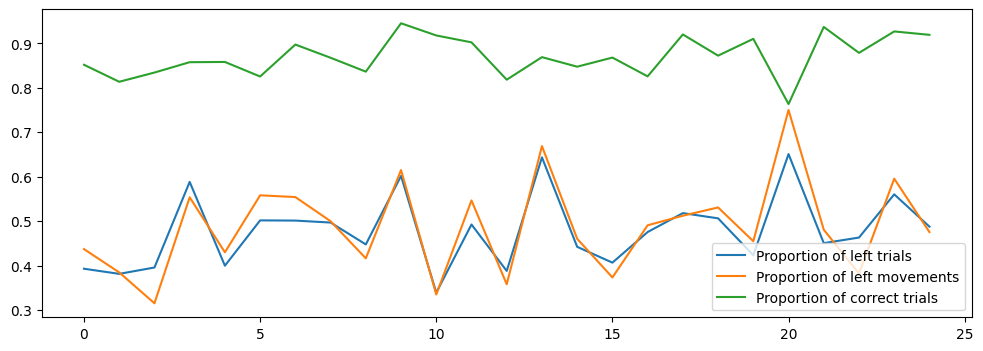

In [90]:
x, q1, q2, q3 = plot_distriubtion(one)

In [ ]:
x

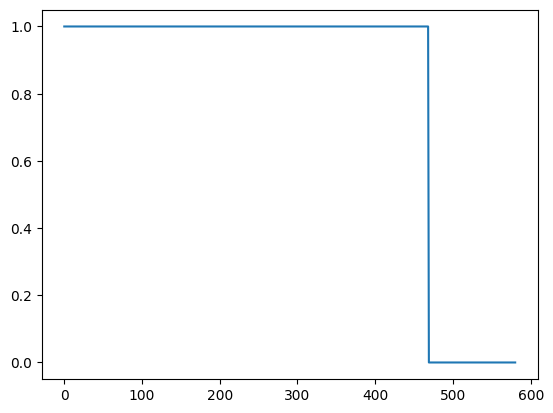

In [77]:
plt.plot(q3[0])

In [626]:
# now for the aggeegate regions
def plot_everything_behavior(normalization='neuron', mean=False):
    stim_data, hits_per_stim = gather_data('stim',normalization)
    feedback_data, hits_per_feedback = gather_data('feedback',normalization)
    choice_data, hits_per_choice = gather_data('choice',normalization)
    plot_epochs(stim_data, choice_data, feedback_data, df_region_mapping, compute_mean_across_regions=mean,scatter=True)

100%|██████████| 22/22 [00:00<00:00, 1756.24it/s]


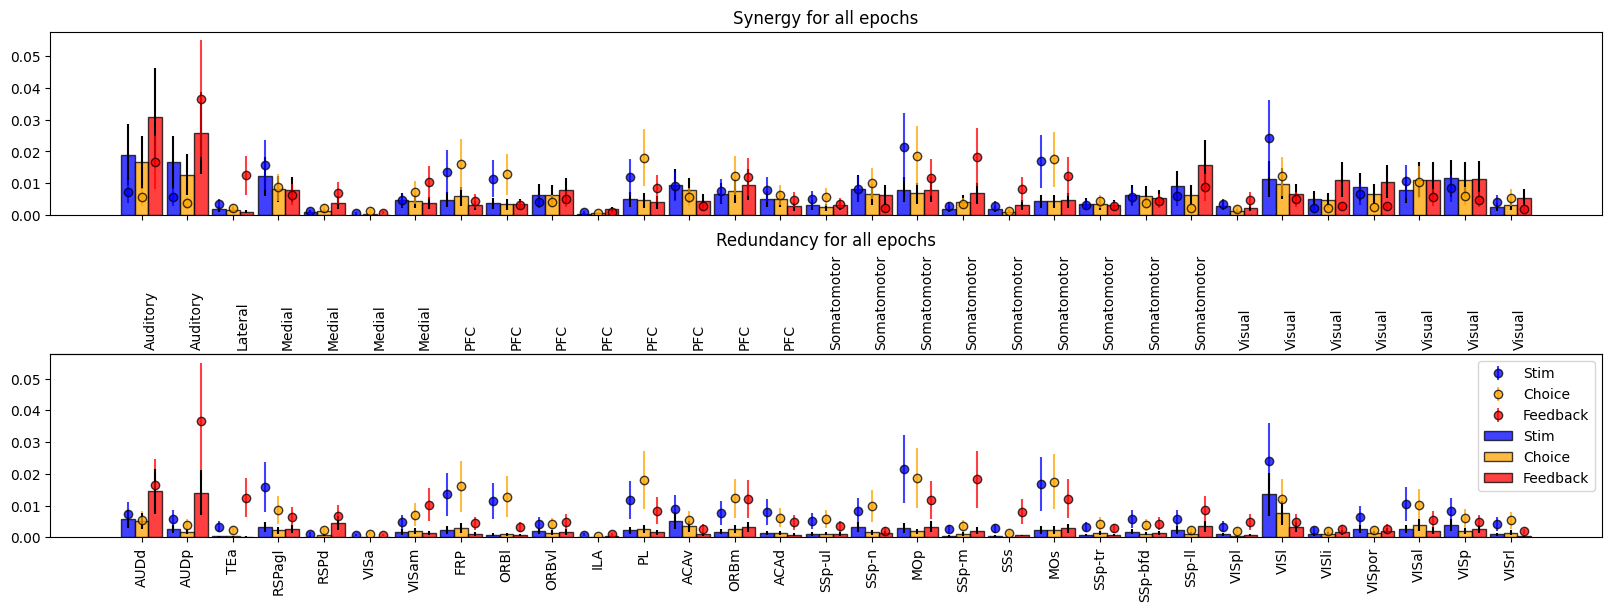

In [642]:
plot_everything_behavior('neuron')

100%|██████████| 22/22 [00:00<00:00, 2059.11it/s]


here i am


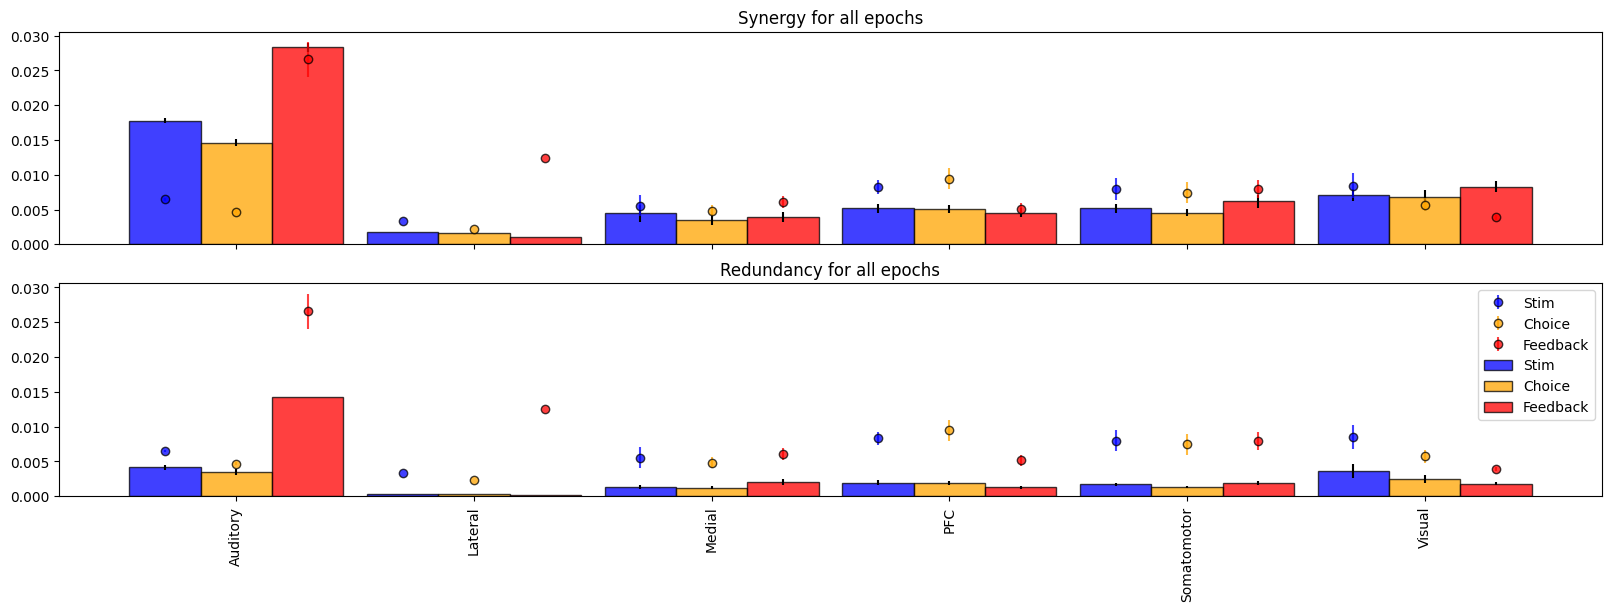

In [643]:
plot_everything_behavior('neuron', mean=True)

In [183]:
# now for regions

In [186]:
with open('../data/interim/hieararchy insertions/regional_information/034e726f-b35f-41e0-8d6c-a22cc32391fb_choice_neuron_neural.pkl','rb') as f:
    data = pkl.load(f)

In [202]:
def gather_data_neuron(key):
    """
    Returns the data for each region depending on the key and the normalization

    Args:
        key (string): Epoch to consider
        norm (string): Normalization to load

    Returns:
        region (dict): All regions for a particular epoch
    """
    files = glob(f'../data/interim/hieararchy insertions/regional_information/*{key}*.pkl')
    regions = {}
    # labels = ['u1','u2','red','syn','mi_yx1','mi_yx2','coinfo','mi_yx1x2']

    for each_file in tqdm(files):
        with open(each_file,'rb') as f:
            data = pkl.load(f)  
        
        for k in data.keys():
            pid_region = data[k]
            # now for each region, we compute the mean syn and red
            mean_synergy = np.mean(pid_region,axis=0)[3]
            mean_redundancy = np.mean(pid_region,axis=0)[2]
            mean_mutual_information = np.mean(pid_region,axis=0)[7]
            mean_unique = (np.mean(pid_region,axis=0)[0] + np.mean(pid_region,axis=0)[1])/2

            if k in regions.keys():
                regions[k].append([mean_synergy, mean_redundancy, mean_mutual_information, mean_unique])
            else:
                regions[k] = [[mean_synergy, mean_redundancy, mean_mutual_information, mean_unique]]
    return regions

In [234]:
def plot_everything_neuron(mean=False, scatter=False):
    stim_data = gather_data_neuron('stim')
    feedback_data = gather_data_neuron('feedback')
    choice_data = gather_data_neuron('choice')
    plot_epochs(stim_data, choice_data, feedback_data, df_region_mapping, compute_mean_across_regions=mean, scatter=scatter)



In [695]:
stim_data = gather_data_neuron('stim')

100%|██████████| 27/27 [00:00<00:00, 1540.47it/s]


In [700]:
stim_data['AUDd']

[[-1.486720459252512e-11,
  8.831411350486266e-11,
  0.0024669986525487917,
  0.0012334992895509413]]

100%|██████████| 27/27 [00:00<00:00, 2800.77it/s]


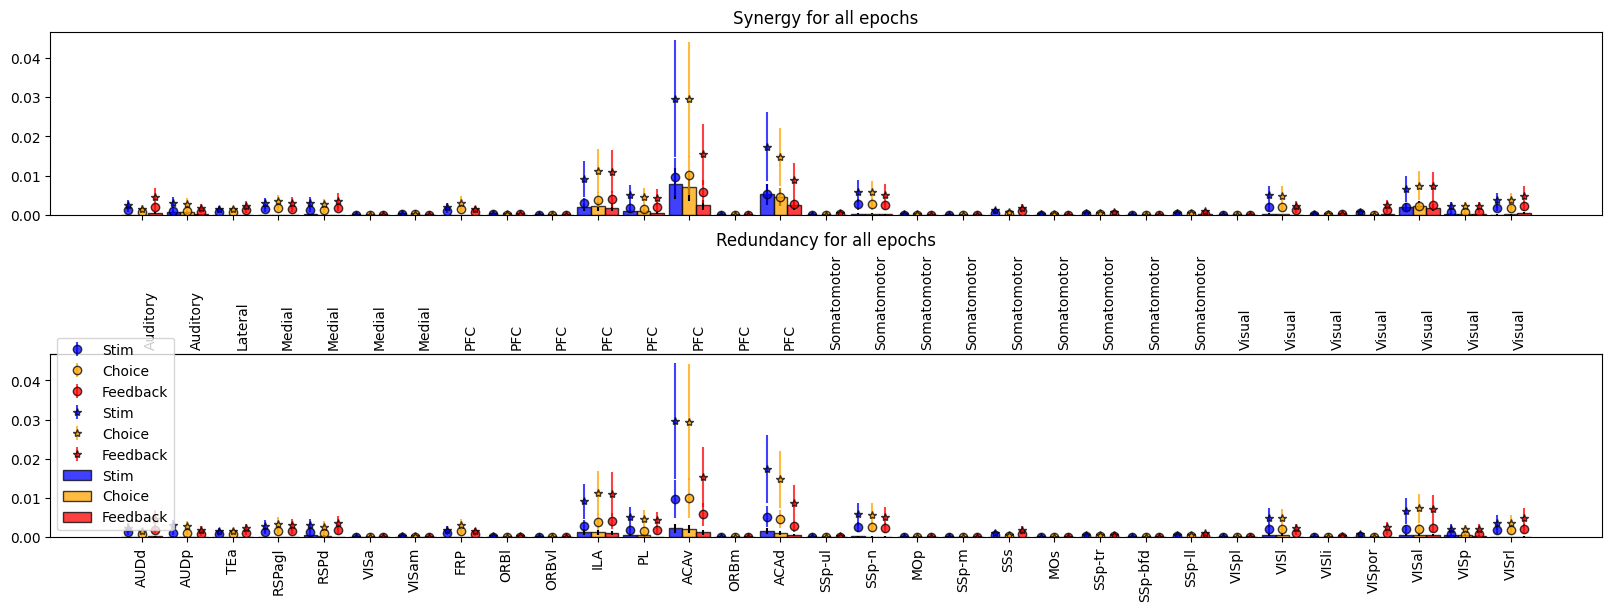

In [699]:
plot_everything_neuron(mean=False, scatter=True)

### Now for Stim, Choice, Feedback, Prior and GLM Fit for good and bad regions

In [29]:
def load_data(location, eid, condition, aggregate=''):
    if condition=='action-kernel' or condition=='glm-hmm':
        aggregate='False'
    with open(Path(location)/f"{eid}_data_redundancy_{condition}_{aggregate}",'rb') as f:
        redundancy = pkl.load(f)
    with open(Path(location)/f"{eid}_data_synergy_{condition}_{aggregate}",'rb') as f:
        synergy = pkl.load(f)
    with open(Path(location)/f"{eid}_data_unique_{condition}_{aggregate}",'rb') as f:
        unique = pkl.load(f)
    with open(Path(location)/f"{eid}_data_coninfo_{condition}_{aggregate}",'rb') as f:
        coninfo = pkl.load(f)
    with open(Path(location)/f"{eid}_data_neuron_{condition}_{aggregate}",'rb') as f:
        mutual_information = pkl.load(f)
    with open(Path(location)/f"{eid}_data_trimI_{condition}_{aggregate}",'rb') as f:
        trivariate_mutual_information = pkl.load(f)
    with open(Path(location)/f"{eid}_data_redundancy_unbiased_{condition}_{aggregate}",'rb') as f:
        redundancy_unbiased = pkl.load(f)
    with open(Path(location)/f"{eid}_data_synergy_unbiased_{condition}_{aggregate}",'rb') as f:
        synergy_unbiased = pkl.load(f)
    with open(Path(location)/f"{eid}_data_unique_unbiased_{condition}_{aggregate}",'rb') as f:
        unique_unbiased = pkl.load(f)

    return redundancy, synergy, unique, coninfo, mutual_information, trivariate_mutual_information, redundancy_unbiased, synergy_unbiased, unique_unbiased
#   return redundancy, synergy, unique, coninfo, mutual_information, trivariate_mutual_information


In [6]:
location = Path('D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp\data\processed')
redundancy, synergy, unique, coninfo, mutual_information, trivariate_mutual_information,redundancy_unbiased, synergy_unbiased, unique_unbiased  = load_data(location, '2e22c1fc-eec6-4856-85a0-7dba8668f646', 'action-kernel')

In [249]:
# 'REGION, REGION': then all associated values
# Idea: again do it on a region by region basis
# data_dict = {}
# for each eid,
#   collate into data_dict the mean value for red, syn, unique, triv for each time point
# okay


1081

In [15]:
location = 'D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp\data\processed\\unbiased\\'

In [26]:
files = glob(location+'*')
eids_to_run = []
for f in files:
    eid = f.rsplit("\\")[-1].rsplit('_data')[0]
    eids_to_run.append(eid)
eids_to_run = np.asarray(list(set(eids_to_run)))

In [30]:
redundancy, synergy, unique, coninfo, mutual_information, trivariate_mutual_information,redundancy_unbiased, synergy_unbiased, unique_unbiased = load_data(location, eid, 'stim')

In [37]:
def collect_data(eid_list, condition, list_regions=None):
    location = Path('D:\personal\phD\code\information-decomposition\ibl-partial-info-decomp\data\processed\\unbiased\\')
    data_trivariate = {}
    for eid in eid_list:
        redundancy, synergy, unique, coninfo, mutual_information, trivariate_mutual_information, redundancy_unbiased, synergy_unbiased, unique_unbiased = load_data(location, eid, condition)

        for k in redundancy.keys(): 
            regiona, regionb = k.rsplit("_")
            if (regiona in list_regions) or (regionb in list_regions):
                mean_redundancy = np.mean(redundancy[k])
                mean_synergy = np.mean(synergy[k])
                mean_trivariate = np.mean(trivariate_mutual_information[k])
                # mean unbiased stuff

                mean_redundancy_unbiased = np.mean(redundancy_unbiased[k])
                mean_synergy_unbiased = np.mean(synergy_unbiased[k])


                if k in data_trivariate.keys():
                    temp = data_trivariate[k]
                    temp.append([mean_redundancy, mean_synergy, mean_trivariate, mean_redundancy_unbiased, mean_synergy_unbiased])
                    data_trivariate[k] = temp
                else:
                    temp = [[mean_redundancy, mean_synergy, mean_trivariate, mean_redundancy_unbiased, mean_synergy_unbiased]]
                    data_trivariate[k] = temp
            else:
                continue
    return data_trivariate

In [38]:
top_bottom_regions = np.array(['APN', 'AUDp', 'BLA', 'BMA', 'COAp', 'ENTm', 'EPd', 'GRN', 'IC',
       'IP', 'MEA', 'OT', 'PA', 'PAG', 'PPN', 'PRNc', 'ProS', 'SPVI', 'LP', 'VISa'
       'SSp-ll', 'VISli', 'VISpm', 'VM'], dtype=object)

#mark as top and bottom at some point

In [39]:
df_granger = pd.read_csv('../data/processed/granger.csv')
df_decoding_region = pd.read_csv('../data/external/region_info.csv')
df_decoding_session_choice = pd.read_parquet('../data/external/choice_stage2.pqt')
df_decoding_session_stim = pd.read_parquet('../data/external/stimside_stage2.pqt')
df_decoding_session_feedback = pd.read_parquet('../data/external/feedback_stage2.pqt')

important_columns = ['Beryl', 'Beryl.1', 'Cosmos', 'Cosmos.1', '# recordings', '# neurons', '# good neurons', 'stim_dec','choice_dec','fback_dec','optBay_dec']

df_decoding_region = df_decoding_region[important_columns]

top_stim_regions = df_decoding_region.sort_values('stim_dec', ascending=False)[0:5]['Beryl'].values
top_choice_regions = df_decoding_region.sort_values('choice_dec', ascending=False)[0:5]['Beryl'].values
top_fback_regions = df_decoding_region.sort_values('fback_dec', ascending=False)[0:5]['Beryl'].values


bottom_stim_regions = df_decoding_region.sort_values('stim_dec', ascending=True)[0:5]['Beryl'].values
bottom_choice_regions = df_decoding_region.sort_values('choice_dec', ascending=True)[0:5]['Beryl'].values
bottom_fback_regions = df_decoding_region.sort_values('fback_dec', ascending=True)[0:5]['Beryl'].values

In [40]:
data_stim = collect_data(eid_list=eids_to_run, condition='stim', list_regions = top_bottom_regions)
data_choice = collect_data(eid_list=eids_to_run, condition='choice', list_regions = top_bottom_regions)
data_feedback = collect_data(eid_list=eids_to_run, condition='feedback', list_regions = top_bottom_regions)
data_glm_hmm = collect_data(eid_list=eids_to_run, condition='glm-hmm', list_regions = top_bottom_regions)
data_action_kernel = collect_data(eid_list=eids_to_run, condition='action-kernel', list_regions = top_bottom_regions)

In [55]:
def plot_data_interval(data, top_regions,title,top_flag=True):

    N = len(data.keys())
    nice_idx = []
    plot_values_mean = np.zeros((N, 5))
    plot_values_std = np.zeros((N, 5))
    
    

    for idx, k in enumerate(data.keys()):
        plot_values_mean[idx,:] = np.nanmean(data[k], axis=0)
        plot_values_std[idx,:] = np.nanstd(data[k], axis=0)/2
        if np.sum(np.round(plot_values_mean[idx,:],6)) == 0:
            nice_idx.append(False)
        else:
            nice_idx.append(True)

    nice_idx = np.asarray(nice_idx)
    N = np.sum(nice_idx)

    #keep count of top regions
    nice_region_idx = []
    ok_region_idx = []
    labels = np.asarray(list(data_stim.keys()))
    labels = labels[nice_idx]

    bar_width = 0.2

    if top_flag:
        for idx, l in enumerate(labels):
            regiona, regionb = l.rsplit('_')
            if (regiona in top_regions) and (regionb in top_regions):
                nice_region_idx.append(idx)
            elif (regiona in top_regions) or (regionb in top_regions):
                ok_region_idx.append(idx)
        

    fig,ax = plt.subplots(figsize=(16,6), nrows=2, sharex=True, sharey=True)
    ax[0].bar(np.arange(N)-0.5*bar_width, plot_values_mean[nice_idx,0], width=bar_width,label='redundancy', yerr=plot_values_std[nice_idx, 0])
    ax[0].bar(np.arange(N)+0.5*bar_width, plot_values_mean[nice_idx,1], width=bar_width, label='synergy', yerr=plot_values_std[nice_idx, 1])
    ax[1].bar(np.arange(N)-0.5*bar_width, plot_values_mean[nice_idx,3], width=bar_width,label='unbiased-redundancy', yerr=plot_values_std[nice_idx, 0])
    ax[1].bar(np.arange(N)+0.5*bar_width, plot_values_mean[nice_idx,4], width=bar_width, label='unbiased-synergy', yerr=plot_values_std[nice_idx, 1])




    # ax.errorbar(np.arange(N), plot_values_mean[nice_idx,2], label='Total mutual information', yerr=plot_values_std[nice_idx, 2],fmt='o',color='red',alpha=0.75, markersize=5)
    
    ax[0].set_xticks(np.arange(N), labels=labels, rotation=90, fontsize=8)
    ax[1].set_xticks(np.arange(N), labels=labels, rotation=90, fontsize=8)
    
    if top_flag:
        xticks = plt.gca().get_xticklabels()
        for i in nice_region_idx:
            xticks[i].set_color('red')  # Change color of specified labels to red
        for i in ok_region_idx:
            xticks[i].set_color('blue')  # Change color of specified labels to red
        
    ax[0].legend()
    ax[1].legend()
    plt.tight_layout()
    ax[0].set_title(title)
    
    



In [53]:
bottom_choice_regions, bottom_stim_regions, bottom_fback_regions

(array(['COAp', 'EPd', 'ProS', 'BLA', 'BMA'], dtype=object),
 array(['SPVI', 'ProS', 'BLA', 'SSp-ll', 'ENTm'], dtype=object),
 array(['OT', 'PA', 'MEA', 'EPd', 'BLA'], dtype=object))

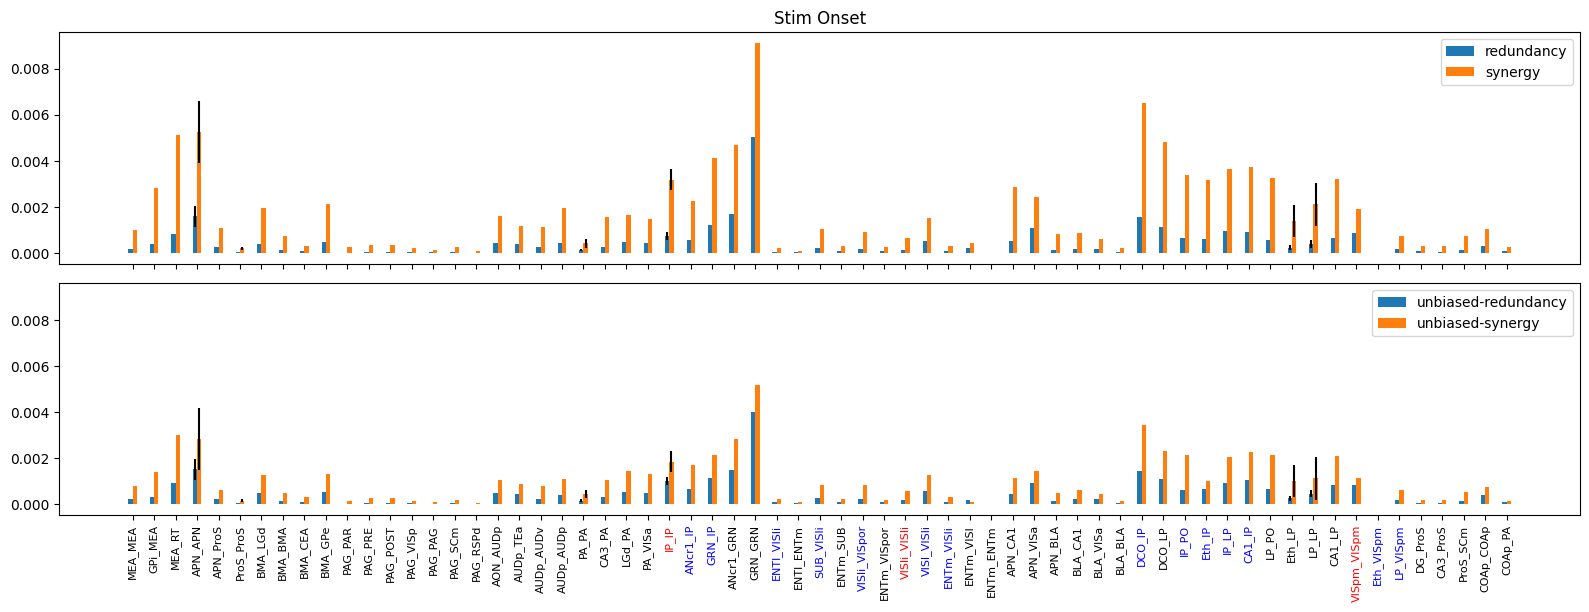

In [56]:
plot_data_interval(data_stim, top_regions=top_stim_regions, title='Stim Onset')

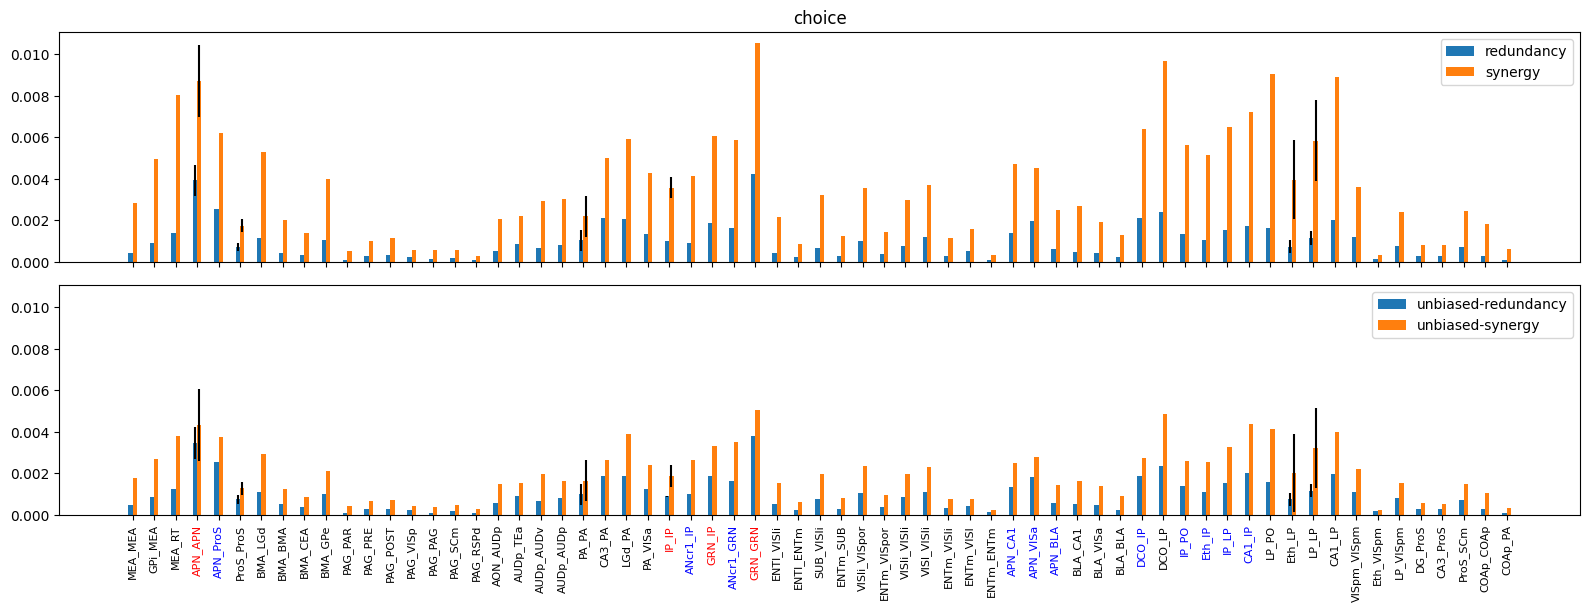

In [57]:
plot_data_interval(data_choice, top_regions=top_choice_regions,title='choice')

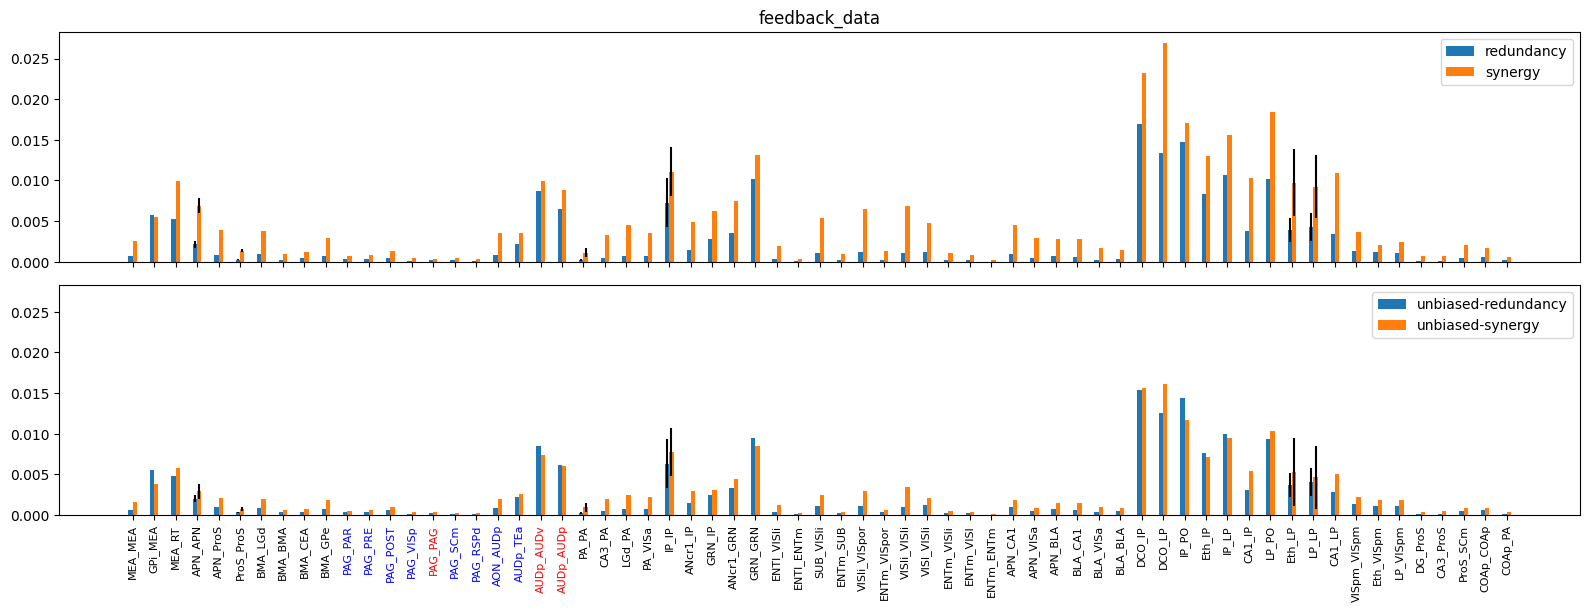

In [58]:
plot_data_interval(data_feedback, top_regions=top_fback_regions, title='feedback_data')

In [59]:
top_regions = np.concatenate([top_stim_regions, top_choice_regions, top_fback_regions])

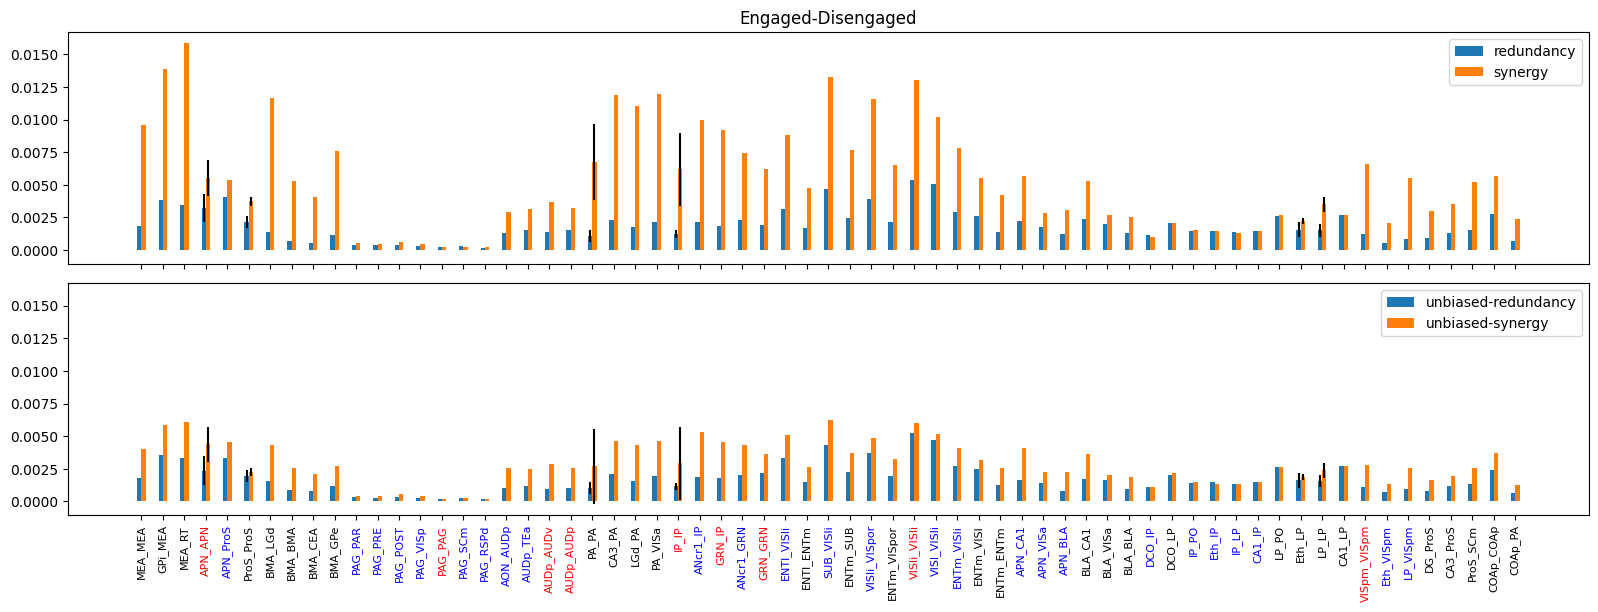

In [60]:
plot_data_interval(data_glm_hmm, top_regions=top_regions,title='Engaged-Disengaged')

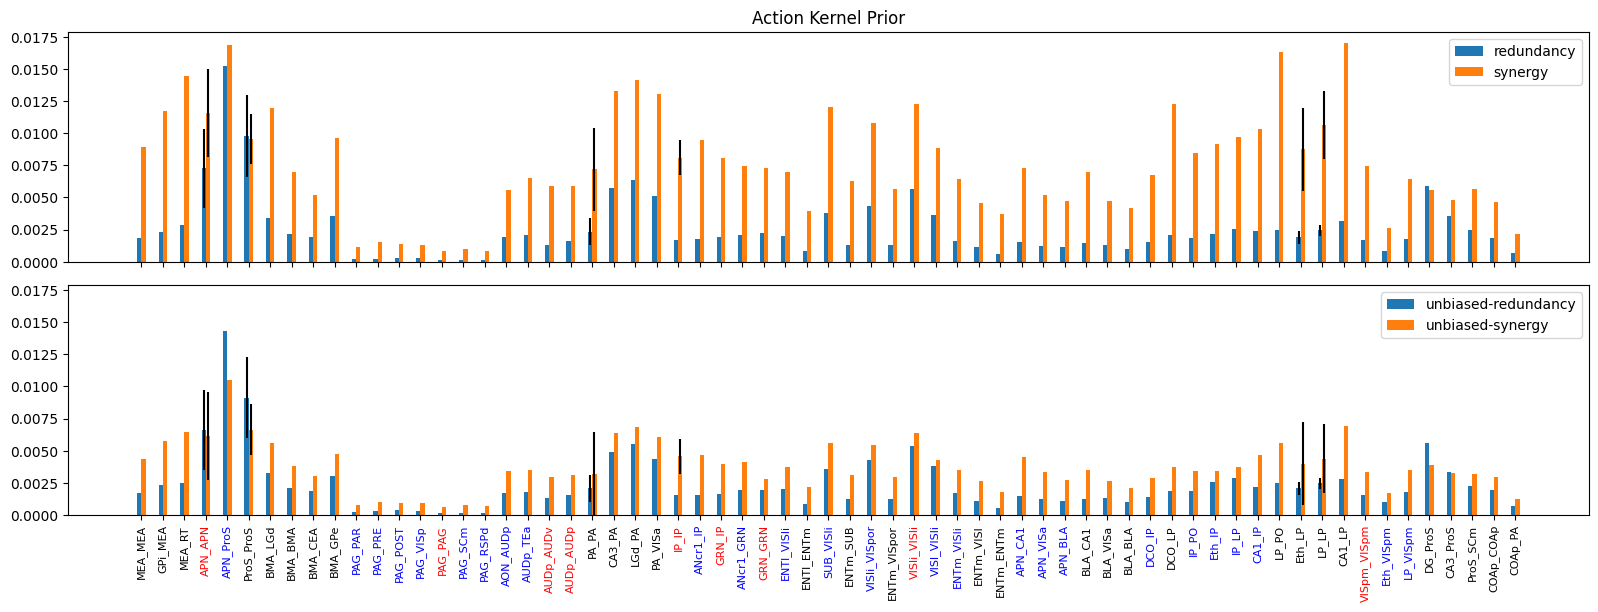

In [61]:
plot_data_interval(data_action_kernel, top_regions=top_regions, title='Action Kernel Prior')

In [51]:
top_regions

array(['VISpm', 'PRNc', 'IP', 'VISli', 'VM', 'PRNc', 'GRN', 'VM', 'IP',
       'APN', 'PPN', 'AUDp', 'PRNc', 'PAG', 'AUDv'], dtype=object)